<a href="https://colab.research.google.com/github/icosrle31/Test_ENNOH/blob/main/PEMMDB_reading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
packages installation

In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)


Mounted at /content/drive


In [ ]:
# Import packages
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT_DIR = os.getcwd()
PROJECT_DIR = os.path.join(ROOT_DIR, "drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/data")


# PEMMDB data reading

In [ ]:
# Define the list of Italian zones and initialize the capacities dictionary
zones = ["ITSI", "ITSA", "ITS1", "ITN1", "ITCS", "ITCN", "ITCA"]
year = 2040
capacities = {}

In [ ]:
def extract_zone_capacities_with_other_RES_profiles(file_path, year):
    xls = pd.ExcelFile(file_path)
    zone_results = {}

    # 1. Horizontal Layout: Battery & Electrolyser
    for sheet in ['Battery', 'Electrolyser']:
        df = pd.read_excel(xls, sheet_name=sheet)
        params = df.iloc[6].dropna()
        vals = df.iloc[10].loc[params.index]
        zone_results[sheet] = dict(zip(params.values, vals.values))

    # 2. Solar
    df_solar = pd.read_excel(xls, sheet_name='Solar')
    solar_data = df_solar.iloc[7:12, 0:2].dropna()
    zone_results['Solar'] = dict(zip(solar_data.iloc[:, 0].astype(str), solar_data.iloc[:, 1]))

    # 3. Wind
    df_wind = pd.read_excel(xls, sheet_name='Wind')
    wind_data = df_wind.iloc[6:8, 0:2].dropna()
    zone_results['Wind'] = dict(zip(wind_data.iloc[:, 0].astype(str), wind_data.iloc[:, 1]))

    # 4. Hydro
    df_hydro = pd.read_excel(xls, sheet_name='Hydro', skiprows=5)
    valid_hydro = df_hydro.dropna(subset=[df_hydro.columns[0], df_hydro.columns[1]])
    zone_results['Hydro'] = dict(zip(valid_hydro.iloc[:, 0].astype(str), valid_hydro.iloc[:, 1]))

    # 5. Other RES: Capacity + Hourly Profile
    try:
        df_other_meta = pd.read_excel(xls, sheet_name='Other RES', header=None, nrows=9)
        other_name = str(df_other_meta.iloc[7, 0])
        other_val = df_other_meta.iloc[7, 1]

        df_profile = pd.read_excel(xls, sheet_name='Other RES', header=9)

        # Standardize datetime parsing for the given year
        dates = df_profile.iloc[:, 0].astype(str).str.strip()
        times = df_profile.iloc[:, 1].astype(int) - 1 # Convert 1-24 to 0-23

        # Construct datetime strings dynamically using the year parameter
        dt_combined = dates.apply(lambda x: x if x.endswith('.') else x + '.') + str(year) + " " + times.apply(lambda x: f"{x:02d}:00:00")
        df_profile['datetime'] = pd.to_datetime(dt_combined, format='%d.%m.%Y %H:%M:%S', errors='coerce')

        profile_series = df_profile.set_index('datetime').iloc[:, 2]

        zone_results['Other RES'] = {
            'capacity': {other_name: other_val},
            'profile': profile_series
        }
    except Exception as e:
        zone_results['Other RES'] = {'error': str(e)}

    return zone_results

# Run extraction for all zones
for zone in zones:
    file_path = os.path.join(PROJECT_DIR, f"PEMMDB/{year}/PEMMDB_{zone}_NationalTrends_{year}.xlsx")
    try:
        capacities[zone] = extract_zone_capacities_with_other_RES_profiles(file_path, year)
        print(f"\u2705 Processed capacities for {zone}")
    except Exception as e:
        print(f"\u274c Error processing {zone} at {file_path}: {e}")

✅ Processed capacities for ITSI
✅ Processed capacities for ITSA
✅ Processed capacities for ITS1
✅ Processed capacities for ITN1
✅ Processed capacities for ITCS
✅ Processed capacities for ITCN
✅ Processed capacities for ITCA


In [ ]:
capacities

{'ITSI': {'Battery': {'Type': 'Battery',
   'Net maximum capacity - generation perspective \n(MW)': 4467,
   'Net maximum capacity - demand perspective \n(MW)': 4467,
   'Storage capacity \n(MWh)': 34088,
   'Number of units': 40,
   'Average efficiency': 0.9199999999999998,
   'Ramp up rate \n(MW/h)': 0,
   'Ramp down rate \n(MW/h)': 0},
  'Electrolyser': {'Type': 'Electrolyser',
   'Net maximum capacity \n(MW)': 1287.33,
   'Number of units': 2,
   'Average efficiency': 0.68,
   'H2 storage \n(GWh)': 0,
   'Ramp up rate \n(MW/h)': 0,
   'Ramp down rate \n(MW/h)': 0,
   'Fixed generation reduction (% of max power output)': 0},
  'Solar': {'Installed capacities Photovoltaic (GW):': 11.4,
   'Installed capacities Rooftop (GW):': 1.653698329299927,
   'Installed capacities Solar Thermal with Storage (GW):': 0,
   'Storage capacities Solar Thermal with Storage (GWh):': 0},
  'Wind': {'Installed capacities Onshore wind (GW):': 4.246,
   'Installed capacities Offshore wind (GW):': 3.2},
  '

#### Data Presentation

In [ ]:
import pandas as pd

# Create a summary table for verification
summary_data = []
for zone, data in capacities.items():
    summary_data.append({
        'Zone': zone,
        'Solar PV (GW)': data['Solar'].get('Installed capacities Photovoltaic (GW):', 0),
        'Solar Rooftop (GW)': data['Solar'].get('Installed capacities Rooftop (GW):', 0),
        'Onshore Wind (GW)': data['Wind'].get('Installed capacities Onshore wind (GW):', 0),
        'Offshore Wind (GW)': data['Wind'].get('Installed capacities Offshore wind (GW):', 0),
        'Battery (MW)': data['Battery'].get('Net maximum capacity - generation perspective \n(MW)', 0),
        'Electrolyser (MW)': data['Electrolyser'].get('Net maximum capacity \n(MW)', 0),
        'Hydro RoR (MW)': data['Hydro'].get('Run of River - Total turbining capacity (MW)', 0)
    })

df_capacities_summary = pd.DataFrame(summary_data)
display(df_capacities_summary)

# Verify Other RES Profile consistency
print("\n--- Other RES Profile Verification ---")
for zone in zones:
    if 'Other RES' in capacities[zone] and 'profile' in capacities[zone]['Other RES']:
        length = len(capacities[zone]['Other RES']['profile'])
        mean_val = capacities[zone]['Other RES']['profile'].mean()
        print(f"{zone}: Profile Length = {length}, Mean Output = {mean_val:.2f} MW")

,Zone,Solar PV (GW),Solar Rooftop (GW),Onshore Wind (GW),Offshore Wind (GW),Battery (MW),Electrolyser (MW),Hydro RoR (MW)
0,ITSI,11.400,1.653698,4.24600,3.2,4467.0,1287.33,91.92500
1,ITSA,9.504,0.717471,1.86000,2.6,2917.0,1758.50,81.90500
2,ITS1,17.266,2.057418,7.97800,6.2,6125.5,3835.39,50.03000
3,ITN1,16.000,16.495894,1.02200,0.9,5296.0,1115.69,5710.56310
4,ITCS,18.997,5.396503,5.49800,1.6,4702.1,858.22,696.77254
5,ITCN,4.600,2.608963,0.65900,2.3,1540.0,189.67,293.62000
6,ITCA,5.875,0.656597,1.80282,1.7,1863.0,955.20,125.38500



--- Other RES Profile Verification ---
ITSI: Profile Length = 8760, Mean Output = 55.29 MW
ITSA: Profile Length = 8760, Mean Output = 59.27 MW
ITS1: Profile Length = 8760, Mean Output = 265.70 MW
ITN1: Profile Length = 8760, Mean Output = 950.26 MW
ITCS: Profile Length = 8760, Mean Output = 324.02 MW
ITCN: Profile Length = 8760, Mean Output = 785.88 MW
ITCA: Profile Length = 8760, Mean Output = 107.48 MW


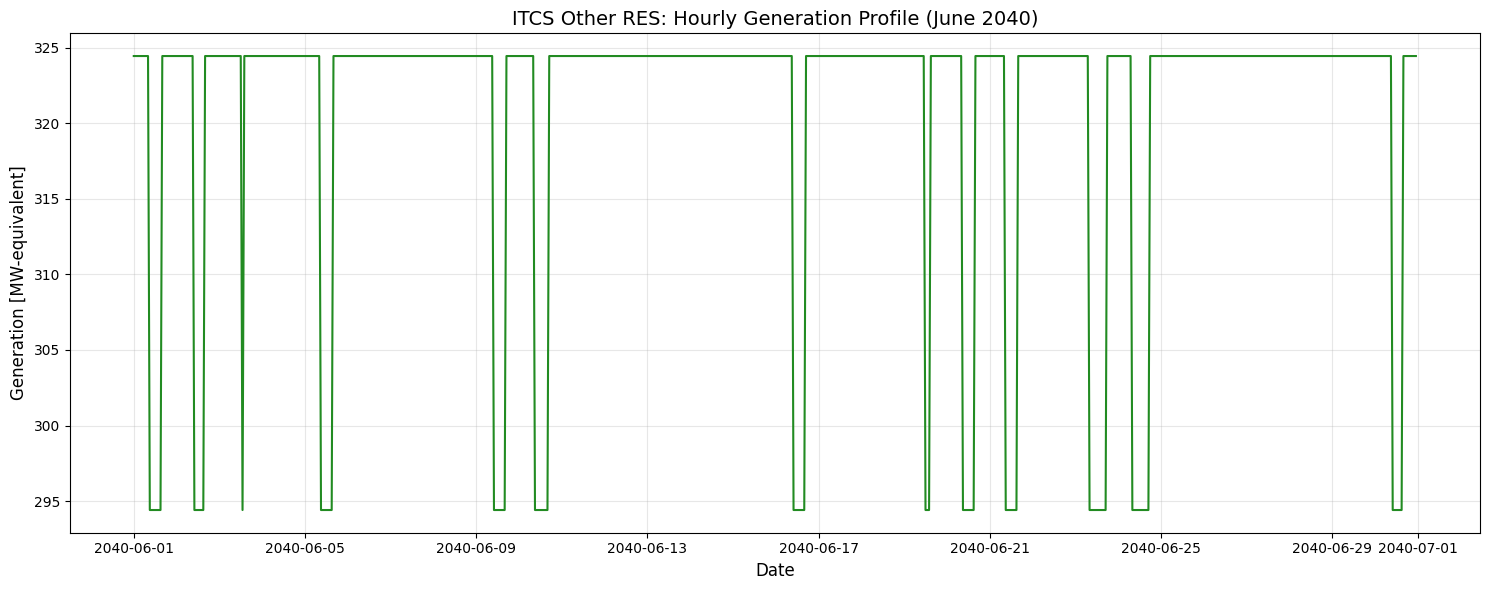

In [ ]:
import matplotlib.pyplot as plt

if 'ITCS' in capacities and 'Other RES' in capacities['ITCS']:
    profile = capacities['ITCS']['Other RES']['profile']
    clean_profile = profile[profile.index.notnull()].sort_index()
    clean_profile = pd.to_numeric(clean_profile, errors='coerce')

    if not clean_profile.empty:
        june_profile = clean_profile.loc[f'{year}-06-01':f'{year}-06-30']

        plt.figure(figsize=(15, 6))
        plt.plot(june_profile.index, june_profile.values, color='forestgreen', linewidth=1.5)
        plt.title(f'ITCS Other RES: Hourly Generation Profile (June {year})', fontsize=14)
        plt.ylabel('Generation [MW-equivalent]', fontsize=12)
        plt.xlabel('Date', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Data cleaning resulted in an empty profile. Check source sheet structure.")
else:
    print('Error: ITCS Other RES data not found.')

In [ ]:
import json
import os
import numpy as np
import pandas as pd

# Define a custom encoder to handle NumPy types and Pandas Series/Timestamps
class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, pd.Series):
            # Convert DatetimeIndex keys to strings for JSON compatibility
            return {str(k): float(v) if pd.notna(v) else None for k, v in obj.to_dict().items()}
        if isinstance(obj, pd.Timestamp):
            return str(obj)
        return super(NpEncoder, self).default(obj)

# Define directory and file path
output_dir = os.path.join(ROOT_DIR, "drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/data/Italy")
os.makedirs(output_dir, exist_ok=True)
file_path = os.path.join(output_dir, f"capacity_{year}.json")

# Save to JSON
with open(file_path, 'w') as f:
    json.dump(capacities, f, cls=NpEncoder, indent=4)

print(f"\u2705 Capacities dictionary successfully saved to: {file_path}")

✅ Capacities dictionary successfully saved to: /content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/data/Italy/capacity_2040.json
